# Instant Funded Account Hedge Model

**Account type:** Instant funded FX accounts
**Structure:** Pay a premium fee upfront and start funded immediately
**Model focus:** First-payout EV under static or trailing drawdown, with optional consistency stress tests

## Key question

> After paying the inflated fee upfront, which instant-funded offers still leave positive value on the first payout?

**Reference:** [instant-funded-hedge-model.md](../../directives/Business/instant-funded-hedge-model.md)

## 0 - Setup

In [1]:
import sys, os, json, math, glob, re
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mtick

WS_ROOT = os.environ.get(
    "WORKSPACE_ROOT",
    r"C:\Users\sossi\Desktop\Business\Orchestrator Hedge Edge"
)
if WS_ROOT not in sys.path:
    sys.path.insert(0, WS_ROOT)

STRATEGY_ROOT = os.path.join(WS_ROOT, "Business", "STRATEGY")
DATA_DIR = os.path.join(STRATEGY_ROOT, "resources", "PropFirmData")

plt.style.use("seaborn-v0_8-darkgrid")
plt.rcParams["figure.figsize"] = (12, 6)
plt.rcParams["figure.dpi"] = 120

FIRST_PAYOUT_TARGET_PCT = 0.05
SPREAD_COST_PCT = 0.0003
BASE_TRADING_DAYS = 5
ASSUME_UNSPECIFIED_AS = "static"
DEFAULT_LEVERAGE = 30

print("Instant-funded hedge model ready.")
print(f"Defaults: payout={FIRST_PAYOUT_TARGET_PCT*100:.0f}%, spread={SPREAD_COST_PCT:.4f}, base_days={BASE_TRADING_DAYS}")

Instant-funded hedge model ready.
Defaults: payout=5%, spread=0.0003, base_days=5


## 1 - Load and Model Instant-Funded Rows

In [2]:
json_files = glob.glob(os.path.join(DATA_DIR, "propmatch_challenges_*.json"))
if not json_files:
    raise FileNotFoundError("No FX challenge data found. Run: python propmatch_scraper.py --action scrape-challenges")

latest = max(json_files, key=os.path.getmtime)
with open(latest, "r", encoding="utf-8") as f:
    raw = json.load(f)

rows = raw.get("challenges", raw if isinstance(raw, list) else [])
instant_rows = [row for row in rows if str(row.get("steps_label", "")).strip().lower() == "instant"]
if not instant_rows:
    raise ValueError("No instant-funded rows found in latest FX scrape.")

def parse_number(val):
    if isinstance(val, (int, float)):
        return float(val)
    text = str(val or "").strip()
    if not text or text == '-' or text.lower() == 'none':
        return 0.0
    cleaned = re.sub(r'[^\d.]', '', text.replace(',', ''))
    return float(cleaned) if cleaned else 0.0

def pct_to_ratio(val):
    num = parse_number(val)
    return num / 100.0 if num > 1 else num

def classify_drawdown(val):
    text = str(val or "").strip().lower()
    if not text or text == '-':
        return "unspecified"
    if "trail" in text or "highest" in text:
        return "trailing"
    if "balance based" in text or "static" in text:
        return "static"
    return "unspecified"

def extract_consistency_ratio(challenge):
    keys = [
        "consistency_rule", "consistency_rule_pct", "consistency_threshold",
        "consistency_threshold_pct", "max_daily_profit_pct", "daily_consistency_pct",
        "profit_consistency_pct"
    ]
    ratios = []
    for key in keys:
        value = challenge.get(key)
        if isinstance(value, dict):
            for nested in value.values():
                ratio = pct_to_ratio(nested)
                if ratio > 0:
                    ratios.append(ratio)
        else:
            ratio = pct_to_ratio(value)
            if ratio > 0:
                ratios.append(ratio)
    return min(ratios) if ratios else 0.0

def normalise(row):
    return {
        "firm": row.get("firm", "Unknown"),
        "account_size": parse_number(row.get("account_size")),
        "fee": parse_number(row.get("fee_discounted") or row.get("fee_original") or row.get("fee_assumed")),
        "max_dd_ratio": pct_to_ratio(row.get("max_drawdown_pct")),
        "daily_dd_ratio": pct_to_ratio(row.get("daily_drawdown_pct")),
        "profit_split": pct_to_ratio(row.get("profit_split_pct") or 80),
        "dd_type": classify_drawdown(row.get("drawdown_type")),
        "payout_timing": row.get("payout_timing", ""),
        "consistency_ratio": extract_consistency_ratio(row),
    }

def compute_instant_hedge(challenge, first_payout_target_pct=FIRST_PAYOUT_TARGET_PCT, consistency_override=None):
    account_size = challenge["account_size"]
    fee = challenge["fee"]
    max_dd_ratio = challenge["max_dd_ratio"]
    split = challenge["profit_split"]
    consistency_ratio = challenge["consistency_ratio"] if consistency_override is None else consistency_override
    effective_dd_type = challenge["dd_type"] if challenge["dd_type"] != "unspecified" else ASSUME_UNSPECIFIED_AS
    if account_size <= 0 or fee <= 0 or max_dd_ratio <= 0 or split <= 0:
        return None

    dd_dollars = account_size * max_dd_ratio
    gross_payout = account_size * first_payout_target_pct
    funded_payout = gross_payout * split
    min_days = math.ceil(1.0 / consistency_ratio) if consistency_ratio > 0 else 1
    trading_days = max(BASE_TRADING_DAYS, min_days)
    daily_profit = gross_payout / trading_days
    insured_base = fee
    total_spread = 0.0
    peak_hedge_notional = 0.0

    if effective_dd_type == "trailing":
        for _ in range(trading_days):
            hedge_notional = insured_base / max_dd_ratio
            peak_hedge_notional = max(peak_hedge_notional, hedge_notional)
            hedge_loss = daily_profit * insured_base / dd_dollars
            spread_drag = hedge_notional * SPREAD_COST_PCT * 2
            total_spread += spread_drag
            insured_base += hedge_loss + spread_drag
    else:
        hedge_notional = insured_base / max_dd_ratio
        peak_hedge_notional = hedge_notional
        for _ in range(trading_days):
            hedge_loss = hedge_notional * (daily_profit / account_size)
            spread_drag = hedge_notional * SPREAD_COST_PCT * 2
            total_spread += spread_drag
            insured_base += hedge_loss + spread_drag

    total_cost = insured_base
    ev = funded_payout - total_cost
    breakeven_pct = ((total_cost / split) / account_size) * 100 if account_size > 0 else 0.0
    capital_required = (peak_hedge_notional / DEFAULT_LEVERAGE) * 1.5 if peak_hedge_notional > 0 else 0.0
    return {
        "firm": challenge["firm"],
        "account_size": account_size,
        "fee": round(fee, 2),
        "dd_type": challenge["dd_type"],
        "effective_dd_type": effective_dd_type,
        "max_dd_pct": round(max_dd_ratio * 100, 2),
        "profit_split_pct": round(split * 100, 1),
        "consistency_ratio": round(consistency_ratio, 4),
        "trading_days": trading_days,
        "payout_timing": challenge["payout_timing"],
        "funded_payout": round(funded_payout, 2),
        "total_cost": round(total_cost, 2),
        "EV": round(ev, 2),
        "breakeven_pct": round(breakeven_pct, 2),
        "capital_required": round(capital_required, 2),
        "capital_efficiency": round(ev / capital_required, 4) if capital_required > 0 else 0.0,
    }

parsed = [normalise(row) for row in instant_rows]
parsed = [row for row in parsed if row["account_size"] > 0 and row["fee"] > 0 and row["max_dd_ratio"] > 0]
results = [compute_instant_hedge(row) for row in parsed]
results = [row for row in results if row is not None]
df = pd.DataFrame(results)

print(f"Loaded instant-funded offers: {len(df)}")
print(f"Drawdown mix: {df['effective_dd_type'].value_counts().to_dict()}")
print(f"Positive EV: {(df['EV'] > 0).sum()} / {len(df)}")
df.head(10)

Loaded instant-funded offers: 63
Drawdown mix: {'trailing': 46, 'static': 17}
Positive EV: 46 / 63


,firm,account_size,fee,dd_type,effective_dd_type,max_dd_pct,profit_split_pct,consistency_ratio,trading_days,payout_timing,funded_payout,total_cost,EV,breakeven_pct,capital_required,capital_efficiency
0,FundingPips,5000.0,69.00,trailing,trailing,5.0,95.0,0.0,5,Bi-weekly,237.5,180.45,57.05,3.80,148.89,0.3832
1,FundedNext,2000.0,59.99,unspecified,static,6.0,70.0,0.0,5,On demand (With condition) & Biweekly,70.0,112.98,-42.98,8.07,49.99,-0.8598
2,Goat Funded Trader,5000.0,68.00,unspecified,static,4.0,80.0,0.0,5,Bi-weekly | First Payout on demand as add-on w...,200.0,158.10,41.90,3.95,85.00,0.4929
3,Blueberry Funded,25000.0,42.50,trailing,trailing,4.0,80.0,0.0,5,14 days,1000.0,137.67,862.33,0.69,136.04,6.3389
4,Maven,2000.0,13.00,trailing,trailing,3.0,80.0,0.0,5,Immediate,80.0,59.02,20.98,3.69,72.68,0.2887
5,NEW,5000.0,105.00,trailing,trailing,6.0,88.0,0.0,5,14 days,220.0,236.84,-16.84,5.38,167.73,-0.1004
6,AquaFunded,5000.0,60.00,trailing,trailing,6.0,90.0,0.0,5,14 Days,225.0,135.34,89.66,3.01,95.85,0.9355
7,Top One Trader,5000.0,94.00,trailing,trailing,5.0,80.0,0.0,5,14 Days,200.0,245.83,-45.83,6.15,202.83,-0.2260
8,For Traders,3000.0,46.00,trailing,trailing,5.0,70.0,0.0,5,14 Days,105.0,120.30,-15.30,5.73,99.26,-0.1542
9,QT Funded,5000.0,52.00,static,static,6.0,80.0,0.0,5,14 days,200.0,97.93,102.07,2.45,43.33,2.3554


## 2 - Rankings

In [4]:
rank_cols = [
    "firm", "account_size", "effective_dd_type", "fee", "max_dd_pct",
    "profit_split_pct", "consistency_ratio", "trading_days", "funded_payout",
    "total_cost", "EV", "breakeven_pct", "capital_required", "capital_efficiency", "payout_timing"
]

df.sort_values("EV", ascending=False)[rank_cols].head(30).style.format({
    "account_size": "${:,.0f}",
    "fee": "${:,.2f}",
    "funded_payout": "${:,.2f}",
    "total_cost": "${:,.2f}",
    "EV": "${:,.2f}",
    "breakeven_pct": "{:.2f}%",
    "max_dd_pct": "{:.1f}%",
    "profit_split_pct": "{:.0f}%",
    "consistency_ratio": "{:.0%}",
    "capital_required": "${:,.2f}",
    "capital_efficiency": "{:.4f}",
}).bar(subset=["EV"], color="#5fba7d").set_caption(
    f"Instant-funded rankings by first-payout EV (target {FIRST_PAYOUT_TARGET_PCT*100:.0f}%)"
)

,firm,account_size,effective_dd_type,fee,max_dd_pct,profit_split_pct,consistency_ratio,trading_days,funded_payout,total_cost,EV,breakeven_pct,capital_required,capital_efficiency,payout_timing
55,AquaFunded,"$400,000",trailing,"$2,699.00",6.0%,90%,0%,5,"$18,000.00","$6,087.94","$11,912.06",1.69%,"$4,311.57",2.7628,14 Days
39,Goat Funded Trader,"$400,000",trailing,"$2,998.00",6.0%,80%,0%,5,"$16,000.00","$6,762.37","$9,237.63",2.11%,"$4,789.21",1.9288,Bi-weekly
56,AquaFunded,"$300,000",trailing,"$2,099.00",6.0%,90%,0%,5,"$13,500.00","$4,734.56","$8,765.44",1.75%,"$3,353.09",2.6141,14 days
23,FundingPips,"$200,000",trailing,$998.00,5.0%,95%,0%,5,"$9,500.00","$2,610.02","$6,889.98",1.37%,"$2,153.48",3.1995,Bi-weekly
38,Goat Funded Trader,"$300,000",trailing,"$2,398.00",6.0%,80%,0%,5,"$12,000.00","$5,408.99","$6,591.01",2.25%,"$3,830.73",1.7206,Bi-weekly
57,AquaFunded,"$200,000",static,"$1,265.00",3.0%,90%,0%,5,"$9,000.00","$3,499.83","$5,500.17",1.94%,"$2,108.33",2.6088,14 Days
37,Goat Funded Trader,"$250,000",trailing,"$2,088.00",6.0%,80%,0%,5,"$10,000.00","$4,709.75","$5,290.25",2.35%,"$3,335.52",1.5860,Bi-weekly
59,AquaFunded,"$150,000",trailing,$980.00,6.0%,90%,0%,5,"$6,750.00","$2,210.51","$4,539.49",1.64%,"$1,565.52",2.8997,14 Days
32,Goat Funded Trader,"$200,000",trailing,"$1,708.00",6.0%,80%,0%,5,"$8,000.00","$3,852.61","$4,147.39",2.41%,"$2,728.48",1.5200,Bi-weekly
24,FundingPips,"$100,000",trailing,$499.00,5.0%,95%,0%,5,"$4,750.00","$1,305.01","$3,444.99",1.37%,"$1,076.74",3.1995,Bi-weekly


## 3 - Visuals and Sensitivity

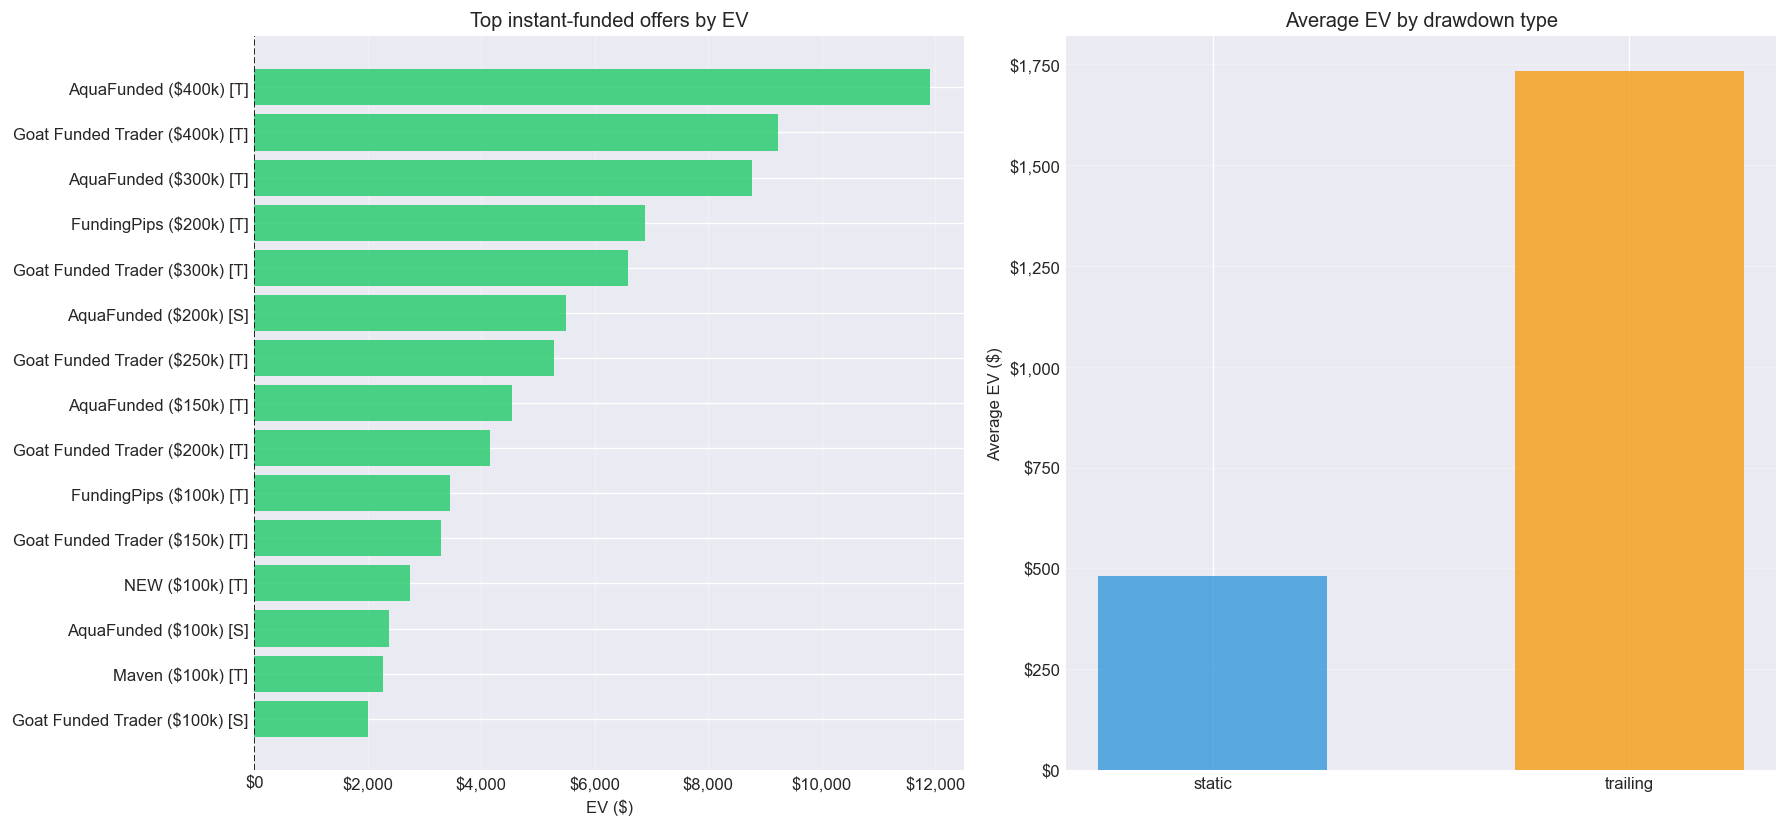

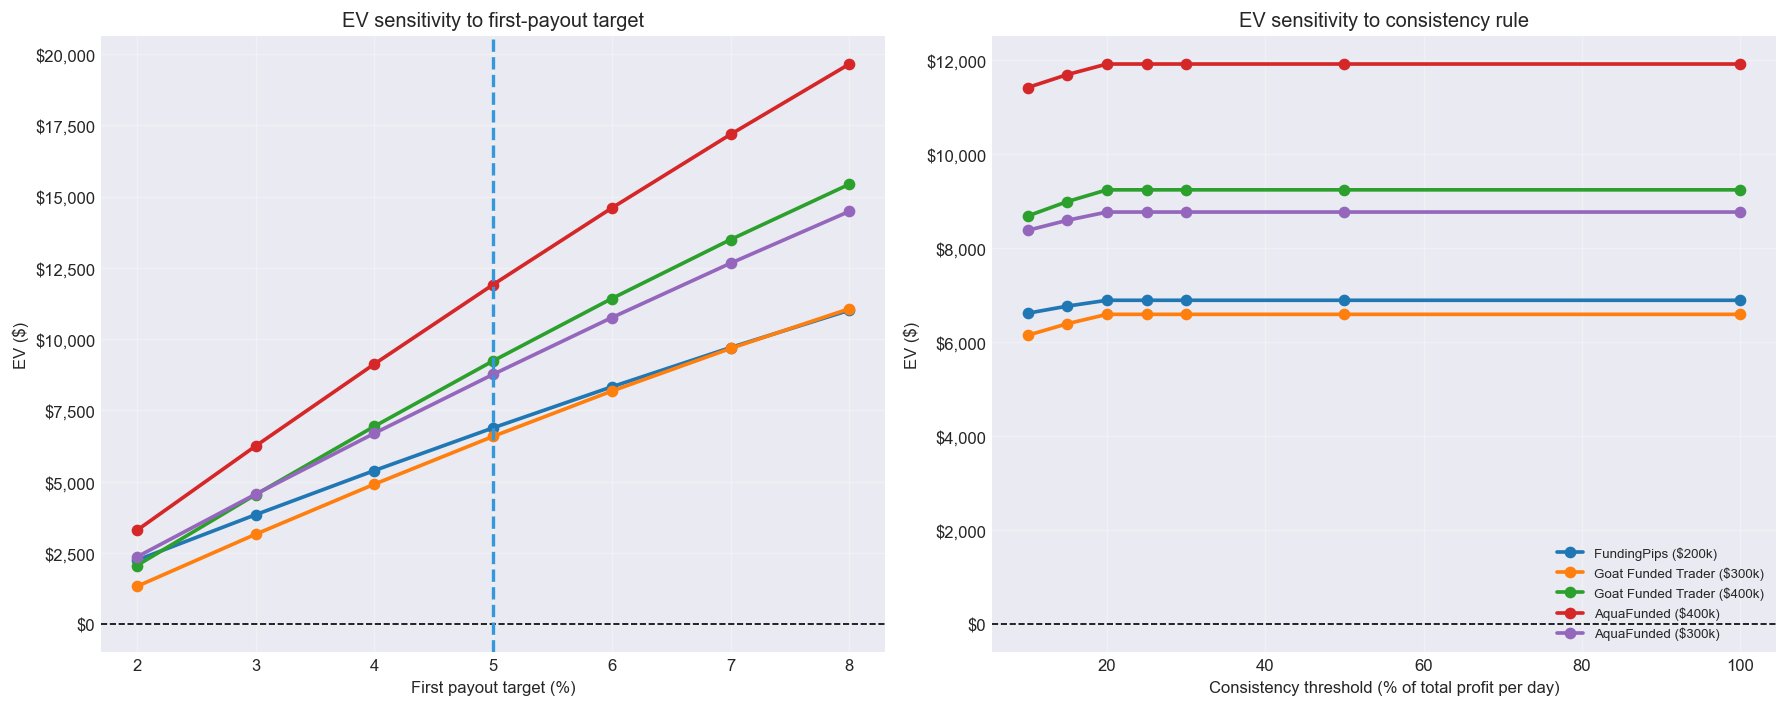

In [5]:
df_show = df.sort_values("EV", ascending=False).head(15).sort_values("EV").copy()
df_show["label"] = df_show.apply(lambda row: f"{row['firm']} (${row['account_size']/1000:.0f}k) [{row['effective_dd_type'][0].upper()}]", axis=1)

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 7))
colors = ["#2ecc71" if value > 0 else "#e74c3c" for value in df_show["EV"]]
ax1.barh(df_show["label"], df_show["EV"], color=colors, alpha=0.85)
ax1.axvline(0, color="black", linestyle="--", linewidth=1)
ax1.set_title("Top instant-funded offers by EV")
ax1.set_xlabel("EV ($)")
ax1.xaxis.set_major_formatter(mtick.FuncFormatter(lambda x, _: f"${x:,.0f}"))
ax1.grid(axis="x", alpha=0.3)

mix = df.groupby("effective_dd_type", as_index=False).agg(avg_ev=("EV", "mean"), avg_cost=("total_cost", "mean"))
ax2.bar(mix["effective_dd_type"], mix["avg_ev"], color=["#3498db", "#f39c12"][:len(mix)], alpha=0.8, width=0.55)
ax2.set_title("Average EV by drawdown type")
ax2.set_ylabel("Average EV ($)")
ax2.yaxis.set_major_formatter(mtick.FuncFormatter(lambda x, _: f"${x:,.0f}"))
ax2.grid(axis="y", alpha=0.3)

plt.tight_layout()
plt.show()

top5 = df.nlargest(5, "EV")[["firm", "account_size"]].apply(tuple, axis=1).tolist()
top5_challenges = [row for row in parsed if (row["firm"], row["account_size"]) in top5]
target_sweep = [value / 100.0 for value in range(2, 9)]
consistency_sweep = [0.10, 0.15, 0.20, 0.25, 0.30, 0.50, 1.00]
colors = plt.cm.tab10.colors

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 6))
for idx, challenge in enumerate(top5_challenges):
    target_evs = [compute_instant_hedge(challenge, first_payout_target_pct=value)["EV"] for value in target_sweep]
    consistency_evs = [compute_instant_hedge(challenge, consistency_override=(None if value >= 1.0 else value))["EV"] for value in consistency_sweep]
    label = f"{challenge['firm']} (${challenge['account_size']/1000:.0f}k)"
    ax1.plot([value * 100 for value in target_sweep], target_evs, marker="o", linewidth=2.2, color=colors[idx % 10], label=label)
    ax2.plot([value * 100 for value in consistency_sweep], consistency_evs, marker="o", linewidth=2.2, color=colors[idx % 10], label=label)

ax1.axhline(0, color="black", linestyle="--", linewidth=1)
ax1.axvline(FIRST_PAYOUT_TARGET_PCT * 100, color="#3498db", linestyle="--", linewidth=2)
ax1.set_title("EV sensitivity to first-payout target")
ax1.set_xlabel("First payout target (%)")
ax1.set_ylabel("EV ($)")
ax1.yaxis.set_major_formatter(mtick.FuncFormatter(lambda x, _: f"${x:,.0f}"))
ax1.grid(alpha=0.3)

ax2.axhline(0, color="black", linestyle="--", linewidth=1)
ax2.set_title("EV sensitivity to consistency rule")
ax2.set_xlabel("Consistency threshold (% of total profit per day)")
ax2.set_ylabel("EV ($)")
ax2.yaxis.set_major_formatter(mtick.FuncFormatter(lambda x, _: f"${x:,.0f}"))
ax2.grid(alpha=0.3)
ax2.legend(fontsize=8, loc="lower right")

plt.tight_layout()
plt.show()

## 4 - Save Output

In [6]:
from datetime import datetime, timezone

ts = datetime.now(timezone.utc).strftime("%Y%m%d_%H%M%S")
output = {
    "generated_at": datetime.now(timezone.utc).isoformat(),
    "model_type": "instant_funded_first_payout",
    "source_file": os.path.basename(latest),
    "first_payout_target_pct": FIRST_PAYOUT_TARGET_PCT * 100,
    "spread_cost_pct": SPREAD_COST_PCT,
    "base_trading_days": BASE_TRADING_DAYS,
    "assume_unspecified_as": ASSUME_UNSPECIFIED_AS,
    "total_offers": len(df),
    "positive_ev_count": int((df["EV"] > 0).sum()),
    "results": results,
}
out_path = os.path.join(DATA_DIR, f"instant_funded_hedge_model_{ts}.json")
with open(out_path, "w", encoding="utf-8") as f:
    json.dump(output, f, indent=2)

print(f"Saved: {os.path.basename(out_path)}")
print(f"Offers: {len(df)}")
print(f"Positive EV: {(df['EV'] > 0).sum()}")

Saved: instant_funded_hedge_model_20260324_230000.json
Offers: 63
Positive EV: 46


## 5 - Summary

- Instant-funded accounts are a separate modelling domain because the upfront fee is paid before any challenge-phase recovery exists.
- Static drawdown keeps recovery costs closer to linear, while trailing drawdown compounds the funded recovery path.
- The notebook defaults missing rule fields to no consistency rule, but still lets you stress-test consistency thresholds.
- First-payout EV is the cleanest lens for comparing whether immediate funding is actually worth the premium fee.